# 双动量回测控制台与分析面板（合并版）

这份 notebook 用于**双动量（Dual Momentum）策略**的日常回测与结果分析，尽量保持和你现有风险平价 notebook 相同的使用习惯，但把“回测控制台”和“结果分析面板”合并成一个文件。

它会完成这些事情：

1. 读取本地市场数据  
2. 设置资产池、双动量参数与回测参数  
3. 运行双动量回测  
4. 查看关键结果与策略快照  
5. 分析净值、回撤、年度收益、月度热力图、调仓/交易统计、选中资产频率  
6. 一键导出结果

> 依赖：`market_data.py`、`backtest.py`、`dual_momentum_backtest_fixed.py`（或 `dual_momentum_backtest.py`）、`dual_momentum_fixed.py`


In [25]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import create_manager, today_str, load_tushare_token
from backtest import build_market_matrices, calc_drawdown

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)

# ========= 让当前目录可导入本地 py 文件 =========
cwd = str(Path.cwd().resolve())
if cwd not in sys.path:
    sys.path.insert(0, cwd)

# ========= 导入双动量回测模块 =========
try:
    dm_bt = importlib.import_module("dual_momentum_backtest_fixed")
    DM_BACKTEST_MODULE = "dual_momentum_backtest_fixed"
except ImportError:
    dm_bt = importlib.import_module("dual_momentum_backtest")
    DM_BACKTEST_MODULE = "dual_momentum_backtest"

simulate_dual_momentum_backtest = dm_bt.simulate_dual_momentum_backtest

print("dual momentum backtest module =", DM_BACKTEST_MODULE)

# ========= 路径与连接 =========
TUSHARE_TOKEN = load_tushare_token()
DB_PATH = "data/db/market_data.db"
EXPORT_DIR = Path("data/exports_dual_momentum")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

manager = create_manager(
    tushare_token=TUSHARE_TOKEN,
    db_path=DB_PATH,
    default_start_date="20150101",
    default_exchange="SSE",
)

print("manager ready")
print("db_path =", Path(DB_PATH).resolve())
print("export_dir =", EXPORT_DIR.resolve())


dual momentum backtest module = dual_momentum_backtest
manager ready
db_path = D:\codeWork\RiskParity\data\db\market_data.db
export_dir = D:\codeWork\RiskParity\data\exports_dual_momentum


In [ ]:
# ========= 资产池 =========

# 可交易风险资产池（示例：A 股宽基 / 行业 / 风格 ETF）
"""
CANDIDATE_ASSETS = [
    "510300.SH",  # 沪深300ETF
    "510500.SH",  # 中证500ETF
    "159915.SZ",  # 创业板ETF
    "588000.SH",  # 科创50ETF
    "515100.SH",  # 红利低波100ETF
    "512660.SH",  # 军工ETF
    "512480.SH",  # 半导体ETF
    "159928.SZ",  # 消费ETF
    "512170.SH",  # 医疗ETF
]
"""

CANDIDATE_ASSETS = [
    "510300.SH",  # 沪深300ETF (核心权益：大盘蓝筹)
    "511090.SH",  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    "159981.SZ",  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ",  # 豆粕ETF (抗通胀：农产品期货)
    "501018.SH",  # 南方原油LOF (抗通胀：国际原油价格)
    "515100.SH",  # 红利低波100ETF (抗通胀：红利股)
]


# 防御资产（风险资产不足 top_k 时承接仓位）
DEFENSIVE_ASSETS = [
    "511010.SH",  # 国债ETF
    "518880.SH",  # 黄金ETF (抗通胀/避险：金属商品)
]

WATCHLIST = list(dict.fromkeys(CANDIDATE_ASSETS + DEFENSIVE_ASSETS))

# ========= 数据区间 =========
START_DATE = "20200101"
END_DATE = today_str()

# ========= 回测参数 =========
BACKTEST_PARAMS = {
    "initial_cash": 1_000_000.0,
    "rebalance_freq": "M",          # D / W / M / Q / Y / W-FRI
    "execution_price_type": "avg",  # open / close / high / low / avg
    "fee_rate_buy": 0.0005,
    "fee_rate_sell": 0.0005,
    "lot_size": 100,
    "max_trade_amount_ratio": 0.05,
    "amount_unit_scale": 1000.0,    # tushare 的 amount 通常按千元
    "use_drift_trigger": False,
    "drift_threshold": 0.05,
    "risk_free_rate": 0.0,          # 设为 0，则夏普更接近“收益风险比”
    "annualization": 252,
    "valuation_ffill_limit": 5,
    "execution_policy": "best_effort",  # best_effort / strict
}

# ========= 双动量预处理参数 =========
DM_PREPARE_KWARGS = {
    "ffill": True,
    "ffill_limit": 5,
    "min_non_na_ratio": 0.0,
    "drop_all_na_dates": True,
}

# ========= 双动量信号参数 =========
DM_SNAPSHOT_KWARGS = {
    "candidate_assets": CANDIDATE_ASSETS,
    "defensive_assets": DEFENSIVE_ASSETS,

    # --- 绝对动量 ---
    "abs_lookback": 60,
    "abs_threshold": 0.0,
    "abs_skip_recent": 0,
    "abs_return_type": "simple",
    "abs_ma_window": 120,          # 若不想用均线过滤，可改为 None
    "abs_ma_type": "sma",          # sma / ema

    # --- 相对动量 ---
    "rel_lookbacks": [20, 60, 120],
    "rel_weights": [0.2, 0.3, 0.5],
    "rel_skip_recent": 0,
    "rel_return_type": "simple",
    "rel_risk_adjusted": False,    # True 时会用波动率做风险调整
    "rel_vol_lookback": 20,

    # --- 组合构建 ---
    "top_k": 3,
    "weighting": "equal",          # equal / score / rank / inv_vol
    "fill_unallocated_to_defensive": True,
    "min_history": 130,
    "max_single_weight": 0.6,

    # --- 市场总开关（可选）---
    "market_asset": "510300.SH",   # 用沪深300ETF 作为市场总开关代理
    "market_lookback": 120,
    "market_threshold": 0.0,
    "market_skip_recent": 0,
    "market_ma_window": None,
    "market_ma_type": "sma",

    # --- 其他 ---
    "use_talib": False,
}

print("watchlist =", WATCHLIST)
print("candidate assets =", CANDIDATE_ASSETS)
print("defensive assets =", DEFENSIVE_ASSETS)
print("params loaded")


watchlist = ['510300.SH', '510500.SH', '159915.SZ', '588000.SH', '515100.SH', '512660.SH', '512480.SH', '159928.SZ', '512170.SH', '511010.SH', '518880.SH']
candidate assets = ['510300.SH', '510500.SH', '159915.SZ', '588000.SH', '515100.SH', '512660.SH', '512480.SH', '159928.SZ', '512170.SH']
defensive assets = ['511010.SH', '518880.SH']
params loaded


In [27]:
# ========= 资产池数据完整性检查 + 自动补齐 =========
import pandas as pd
import numpy as np
from IPython.display import display

# -----------------------------
# 可调参数
# -----------------------------
CHECK_EXCHANGE = "SSE"      # 用于交易日历判断，A 股 ETF/LOF 通常用 SSE 即可
EXTRA_WARMUP_DAYS = 20      # 在策略最小 warmup 基础上再额外预留一些交易日
DO_UPDATE = True            # 只检查不更新时，改成 False
RECHECK_AFTER_UPDATE = True # 更新后是否自动复查

# -----------------------------
# 资产池
# -----------------------------
ASSET_POOL = list(dict.fromkeys(
    globals().get("WATCHLIST")
    or (globals().get("CANDIDATE_ASSETS", []) + globals().get("DEFENSIVE_ASSETS", []))
))

if len(ASSET_POOL) == 0:
    raise ValueError("未找到资产池。请先定义 WATCHLIST，或 CANDIDATE_ASSETS / DEFENSIVE_ASSETS。")

if "manager" not in globals():
    raise ValueError("未找到 manager。请先初始化 market_data manager。")

if "START_DATE" not in globals() or "END_DATE" not in globals():
    raise ValueError("未找到 START_DATE / END_DATE。请先定义回测时间区间。")

DM_KW = globals().get("DM_SNAPSHOT_KWARGS", {})

# -----------------------------
# 工具函数
# -----------------------------
def _to_ts(x):
    return pd.Timestamp(str(x))

def _yyyymmdd(ts):
    return pd.Timestamp(ts).strftime("%Y%m%d")

def _infer_required_trade_days(dm_kw: dict) -> int:
    """
    根据双动量参数，粗略推断策略运行所需的最少历史交易日长度。
    """
    if dm_kw is None:
        return 0

    need = []

    abs_lookback = int(dm_kw.get("abs_lookback", 0) or 0)
    abs_skip_recent = int(dm_kw.get("abs_skip_recent", 0) or 0)
    if abs_lookback > 0:
        need.append(abs_lookback + abs_skip_recent + 1)

    rel_lookbacks = dm_kw.get("rel_lookbacks")
    rel_lookback = dm_kw.get("rel_lookback")
    rel_skip_recent = int(dm_kw.get("rel_skip_recent", 0) or 0)

    if rel_lookbacks is not None:
        need.extend([int(x) + rel_skip_recent + 1 for x in rel_lookbacks])
    elif rel_lookback is not None:
        need.append(int(rel_lookback) + rel_skip_recent + 1)

    abs_ma_window = dm_kw.get("abs_ma_window")
    if abs_ma_window is not None:
        need.append(int(abs_ma_window))

    if bool(dm_kw.get("rel_risk_adjusted", False)):
        rel_vol_lookback = int(dm_kw.get("rel_vol_lookback", 20) or 20)
        need.append(rel_vol_lookback + 1)

    market_lookback = dm_kw.get("market_lookback")
    market_skip_recent = int(dm_kw.get("market_skip_recent", 0) or 0)
    if market_lookback is not None:
        need.append(int(market_lookback) + market_skip_recent + 1)

    market_ma_window = dm_kw.get("market_ma_window")
    if market_ma_window is not None:
        need.append(int(market_ma_window))

    min_history = dm_kw.get("min_history")
    if min_history is not None:
        need.append(int(min_history))

    return int(max(need) if len(need) > 0 else 0)


def _get_open_calendar(exchange: str, start_date: str, end_date: str) -> pd.DatetimeIndex:
    open_dates = manager.store.get_open_trade_dates(
        exchange=exchange,
        start_date=start_date,
        end_date=end_date,
    )
    if open_dates is None or len(open_dates) == 0:
        return pd.DatetimeIndex([])
    cal = pd.to_datetime(pd.Series(open_dates).astype(str), format="%Y%m%d", errors="coerce")
    cal = cal.dropna().drop_duplicates().sort_values()
    return pd.DatetimeIndex(cal)


def _infer_required_start_date(start_date: str, required_trade_days: int, exchange: str, extra_trade_days: int) -> pd.Timestamp:
    """
    根据策略所需 warmup，反推出数据库至少应覆盖到的开始日期。
    """
    start_ts = _to_ts(start_date)

    if required_trade_days <= 0 and extra_trade_days <= 0:
        return start_ts

    # 粗放地往前多取一些自然日，然后用交易日历反推
    approx_back_days = max(120, int((required_trade_days + extra_trade_days) * 2.4))
    cal_start = _yyyymmdd(start_ts - pd.Timedelta(days=approx_back_days))
    cal_end = _yyyymmdd(start_ts)

    cal = _get_open_calendar(exchange=exchange, start_date=cal_start, end_date=cal_end)
    cal = cal[cal <= start_ts]

    if len(cal) == 0:
        return start_ts

    need_back = required_trade_days + extra_trade_days
    idx = max(0, len(cal) - 1 - need_back)
    return pd.Timestamp(cal[idx])


def _infer_expected_latest_trade_date(end_date: str, exchange: str) -> pd.Timestamp:
    """
    取 <= END_DATE 的最后一个开市日，作为数据库应更新到的目标日期。
    """
    end_ts = _to_ts(end_date)
    cal_start = _yyyymmdd(end_ts - pd.Timedelta(days=40))
    cal_end = _yyyymmdd(end_ts)
    cal = _get_open_calendar(exchange=exchange, start_date=cal_start, end_date=cal_end)
    if len(cal) == 0:
        return end_ts
    return pd.Timestamp(cal.max())


def _try_get_list_date_map(ts_codes):
    """
    尽量读取 instrument 的 list_date，避免把上市较晚的标的误判为“起始不足”。
    """
    try:
        inst = manager.store.get_instruments(listed_only=False)
        if inst is None or len(inst) == 0:
            return {}
        required_cols = {"ts_code", "list_date"}
        if not required_cols.issubset(inst.columns):
            return {}
        tmp = inst.loc[inst["ts_code"].isin(ts_codes), ["ts_code", "list_date"]].copy()
        tmp["list_date"] = pd.to_datetime(tmp["list_date"].astype(str), format="%Y%m%d", errors="coerce")
        return tmp.set_index("ts_code")["list_date"].to_dict()
    except Exception as e:
        print(f"[提示] 读取 instruments/list_date 失败，起始覆盖检查将不考虑上市日期：{e}")
        return {}


def _build_integrity_report(ts_codes, required_start_ts, expected_latest_ts, exchange):
    """
    构建完整性检查报表。
    """
    query_start = _yyyymmdd(required_start_ts)
    query_end = _yyyymmdd(expected_latest_ts)

    existing = manager.store.get_daily_prices(
        ts_codes=ts_codes,
        start_date=query_start,
        end_date=query_end,
    )

    if existing is None or len(existing) == 0:
        existing = pd.DataFrame(columns=["trade_date", "ts_code"])

    grp = (
        existing.groupby("ts_code")["trade_date"]
        .agg(db_start="min", db_end="max", actual_rows="nunique")
        .reset_index()
    )

    report = pd.DataFrame({"ts_code": ts_codes}).merge(grp, on="ts_code", how="left")

    report["db_start"] = pd.to_datetime(report["db_start"].astype(str), format="%Y%m%d", errors="coerce")
    report["db_end"] = pd.to_datetime(report["db_end"].astype(str), format="%Y%m%d", errors="coerce")
    report["actual_rows"] = report["actual_rows"].fillna(0).astype(int)

    list_date_map = _try_get_list_date_map(ts_codes)

    open_calendar = _get_open_calendar(
        exchange=exchange,
        start_date=_yyyymmdd(required_start_ts),
        end_date=_yyyymmdd(expected_latest_ts),
    )

    if len(open_calendar) == 0:
        raise ValueError("交易日历为空，无法检查数据完整性。")

    def _effective_required_start(code):
        ld = list_date_map.get(code, pd.NaT)
        if pd.isna(ld):
            return required_start_ts
        return max(required_start_ts, pd.Timestamp(ld))

    report["effective_required_start"] = report["ts_code"].map(_effective_required_start)
    report["expected_latest"] = expected_latest_ts

    def _count_expected_rows(start_ts):
        return int((open_calendar >= pd.Timestamp(start_ts)).sum())

    report["expected_rows"] = report["effective_required_start"].apply(_count_expected_rows)

    report["has_data"] = (report["actual_rows"] > 0).astype(int)
    report["start_ok"] = report["db_start"].notna() & (report["db_start"] <= report["effective_required_start"])
    report["end_ok"] = report["db_end"].notna() & (report["db_end"] >= report["expected_latest"])

    # interior_ok：只要不是 0 行，且行数达到预期交易日数，就认为区间内部基本完整
    # 若存在停牌/长期不交易，也会被标红，这正适合回测前检查
    report["interior_ok"] = (report["actual_rows"] >= report["expected_rows"]) & (report["actual_rows"] > 0)

    report["needs_update"] = ~(report["start_ok"] & report["end_ok"] & report["interior_ok"])

    def _reason(row):
        reasons = []
        if row["has_data"] == 0:
            reasons.append("无数据")
        else:
            if not row["start_ok"]:
                reasons.append("起始不足")
            if not row["end_ok"]:
                reasons.append("未更新到目标结束日")
            if not row["interior_ok"]:
                reasons.append("区间内可能有缺口")
        return "；".join(reasons) if reasons else "OK"

    report["reason"] = report.apply(_reason, axis=1)

    report = report.sort_values(
        by=["needs_update", "reason", "ts_code"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return report, existing


# -----------------------------
# 推断本次回测所需的数据时间范围
# -----------------------------
required_trade_days = _infer_required_trade_days(DM_KW)
required_start_ts = _infer_required_start_date(
    start_date=START_DATE,
    required_trade_days=required_trade_days,
    exchange=CHECK_EXCHANGE,
    extra_trade_days=EXTRA_WARMUP_DAYS,
)
expected_latest_ts = _infer_expected_latest_trade_date(
    end_date=END_DATE,
    exchange=CHECK_EXCHANGE,
)

print("资产池数量：", len(ASSET_POOL))
print("回测设置 START_DATE：", START_DATE)
print("回测设置 END_DATE：", END_DATE)
print("根据双动量参数推断所需最少 warmup 交易日：", required_trade_days)
print("数据库建议覆盖起点：", required_start_ts.strftime("%Y-%m-%d"))
print("数据库应至少更新到：", expected_latest_ts.strftime("%Y-%m-%d"))

# -----------------------------
# 首次检查
# -----------------------------
report_before, existing_before = _build_integrity_report(
    ts_codes=ASSET_POOL,
    required_start_ts=required_start_ts,
    expected_latest_ts=expected_latest_ts,
    exchange=CHECK_EXCHANGE,
)

print("\n[更新前检查结果]")
display(report_before)

to_update = report_before.loc[report_before["needs_update"], "ts_code"].tolist()

if len(to_update) == 0:
    print("\n数据库已满足当前双动量回测要求，无需更新。")
else:
    print("\n需要补齐的标的：", to_update)

    if DO_UPDATE:
        print("\n开始自动补齐数据 ...")
        update_summary = manager.update_daily_prices(
            ts_codes=to_update,
            start_date=_yyyymmdd(required_start_ts),
            end_date=_yyyymmdd(expected_latest_ts),
        )
        print("\n[自动补齐结果]")
        display(update_summary)

        # 可选：对需要补齐的资产再刷新最近 30 天，增强“最新状态”可靠性
        try:
            recent_summary = manager.refresh_recent_daily_prices(
                ts_codes=to_update,
                lookback_days=30,
                end_date=_yyyymmdd(expected_latest_ts),
            )
            print("\n[最近 30 天刷新结果]")
            display(recent_summary)
        except Exception as e:
            print(f"[提示] refresh_recent_daily_prices 执行失败，已跳过：{e}")

        if RECHECK_AFTER_UPDATE:
            report_after, existing_after = _build_integrity_report(
                ts_codes=ASSET_POOL,
                required_start_ts=required_start_ts,
                expected_latest_ts=expected_latest_ts,
                exchange=CHECK_EXCHANGE,
            )
            print("\n[更新后复查结果]")
            display(report_after)

            unresolved = report_after.loc[report_after["needs_update"], "ts_code"].tolist()
            if len(unresolved) == 0:
                print("\n所有资产已满足当前回测要求。")
            else:
                print("\n以下标的更新后仍未完全满足要求，请重点检查：", unresolved)
    else:
        print("\nDO_UPDATE=False，仅完成检查，未执行自动更新。")

资产池数量： 11
回测设置 START_DATE： 20200101
回测设置 END_DATE： 20260327
根据双动量参数推断所需最少 warmup 交易日： 130
数据库建议覆盖起点： 2019-05-24
数据库应至少更新到： 2026-03-24

[更新前检查结果]


,ts_code,db_start,db_end,actual_rows,effective_required_start,expected_latest,expected_rows,has_data,start_ok,end_ok,interior_ok,needs_update,reason
0,159915.SZ,2019-05-24,2026-03-24,1656,2019-05-24,2026-03-24,1657,1,True,True,False,True,区间内可能有缺口
1,512170.SH,2019-06-17,2026-03-24,1641,2019-06-17,2026-03-24,1642,1,True,True,False,True,区间内可能有缺口
2,512480.SH,2019-06-12,2026-03-24,1644,2019-06-12,2026-03-24,1645,1,True,True,False,True,区间内可能有缺口
3,159928.SZ,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
4,510300.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
5,510500.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
6,511010.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
7,512660.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
8,515100.SH,2020-07-03,2026-03-24,1387,2020-07-03,2026-03-24,1387,1,True,True,True,False,OK
9,518880.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK



需要补齐的标的： ['159915.SZ', '512170.SH', '512480.SH']

开始自动补齐数据 ...

[自动补齐结果]


{'instrument_count': 3, 'updated_count': 3, 'inserted_rows': 4941}


[最近 30 天刷新结果]


{'instrument_count': 3, 'updated_count': 3, 'inserted_rows': 63}


[更新后复查结果]


,ts_code,db_start,db_end,actual_rows,effective_required_start,expected_latest,expected_rows,has_data,start_ok,end_ok,interior_ok,needs_update,reason
0,159915.SZ,2019-05-24,2026-03-24,1656,2019-05-24,2026-03-24,1657,1,True,True,False,True,区间内可能有缺口
1,512170.SH,2019-06-17,2026-03-24,1641,2019-06-17,2026-03-24,1642,1,True,True,False,True,区间内可能有缺口
2,512480.SH,2019-06-12,2026-03-24,1644,2019-06-12,2026-03-24,1645,1,True,True,False,True,区间内可能有缺口
3,159928.SZ,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
4,510300.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
5,510500.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
6,511010.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
7,512660.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK
8,515100.SH,2020-07-03,2026-03-24,1387,2020-07-03,2026-03-24,1387,1,True,True,True,False,OK
9,518880.SH,2019-05-24,2026-03-24,1657,2019-05-24,2026-03-24,1657,1,True,True,True,False,OK



以下标的更新后仍未完全满足要求，请重点检查： ['159915.SZ', '512170.SH', '512480.SH']


In [28]:
# ========= 读取市场数据并构建 market 字典 =========
raw_prices = manager.store.get_daily_prices(
    ts_codes=WATCHLIST,
    start_date=START_DATE,
    end_date=END_DATE,
)

print("raw_prices shape =", raw_prices.shape)
display(raw_prices.head())

coverage = raw_prices.groupby("ts_code")["trade_date"].agg(["min", "max", "count"])
display(coverage)

market = build_market_matrices(
    data=raw_prices,
    fields=("open", "high", "low", "close", "amount"),
    date_col="trade_date",
    code_col="ts_code",
    date_format="%Y%m%d",
)

DM_PREPARE_KWARGS["calendar"] = market["close"].index

for k, v in market.items():
    print(k, v.shape)


raw_prices shape = (16247, 14)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,source,created_at,updated_at
0,159915.SZ,20200102,1.743,1.771,1.731,1.765,1.730,0.035,2.0231,3380825.32,593821.307,tushare,2026-03-24 20:53:42,2026-03-27 01:13:28
1,159915.SZ,20200103,1.766,1.774,1.751,1.764,1.765,-0.001,-0.0567,2746860.29,484657.154,tushare,2026-03-24 20:53:42,2026-03-27 01:13:28
2,159915.SZ,20200106,1.756,1.806,1.753,1.788,1.764,0.024,1.3605,4166991.55,744384.661,tushare,2026-03-24 20:53:42,2026-03-27 01:13:28
3,159915.SZ,20200107,1.792,1.823,1.792,1.822,1.788,0.034,1.9016,3945590.43,713661.489,tushare,2026-03-24 20:53:42,2026-03-27 01:13:28
4,159915.SZ,20200108,1.808,1.822,1.789,1.792,1.822,-0.030,-1.6465,4959107.39,894926.575,tushare,2026-03-24 20:53:42,2026-03-27 01:13:28


,min,max,count
ts_code,,,
159915.SZ,20200102,20260326,1507
159928.SZ,20200102,20260324,1506
510300.SH,20200102,20260326,1508
510500.SH,20200102,20260326,1508
511010.SH,20200102,20260326,1508
512170.SH,20200102,20260324,1505
512480.SH,20200102,20260324,1505
512660.SH,20200102,20260324,1506
515100.SH,20200703,20260326,1389


open (1508, 11)
high (1508, 11)
low (1508, 11)
close (1508, 11)
amount (1508, 11)


In [29]:
# ========= 运行回测 =========
result = simulate_dual_momentum_backtest(
    market=market,
    initial_cash=BACKTEST_PARAMS["initial_cash"],
    rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
    execution_price_type=BACKTEST_PARAMS["execution_price_type"],
    valuation_ffill_limit=BACKTEST_PARAMS["valuation_ffill_limit"],
    fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
    fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
    lot_size=BACKTEST_PARAMS["lot_size"],
    max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
    amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
    use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
    drift_threshold=BACKTEST_PARAMS["drift_threshold"],
    dm_prepare_kwargs=DM_PREPARE_KWARGS,
    dm_snapshot_kwargs=DM_SNAPSHOT_KWARGS,
    risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
    annualization=BACKTEST_PARAMS["annualization"],
    include_cash_column=True,
    cash_column_name="CASH",
    store_snapshot_details=True,
    execution_policy=BACKTEST_PARAMS["execution_policy"],
)

summary = result["summary"]
nav_df = result["nav_df"]
returns = result["returns"]
weights_df = result["weights_df"]
positions_df = result["positions_df"]
target_weights_df = result["target_weights_df"]
trades_df = result["trades_df"]
rebalance_log_df = result["rebalance_log_df"]
snapshot_log_df = result["snapshot_log_df"]
snapshot_details = result.get("snapshot_details", {})

print("回测完成")
display(summary.to_frame("value"))


回测完成


,value
total_return,-0.286829
annual_return,-0.054958
excess_return,-0.054958
annual_volatility,0.209146
sharpe_ratio,-0.159436
max_drawdown,-0.482244
calmar_ratio,-0.113963


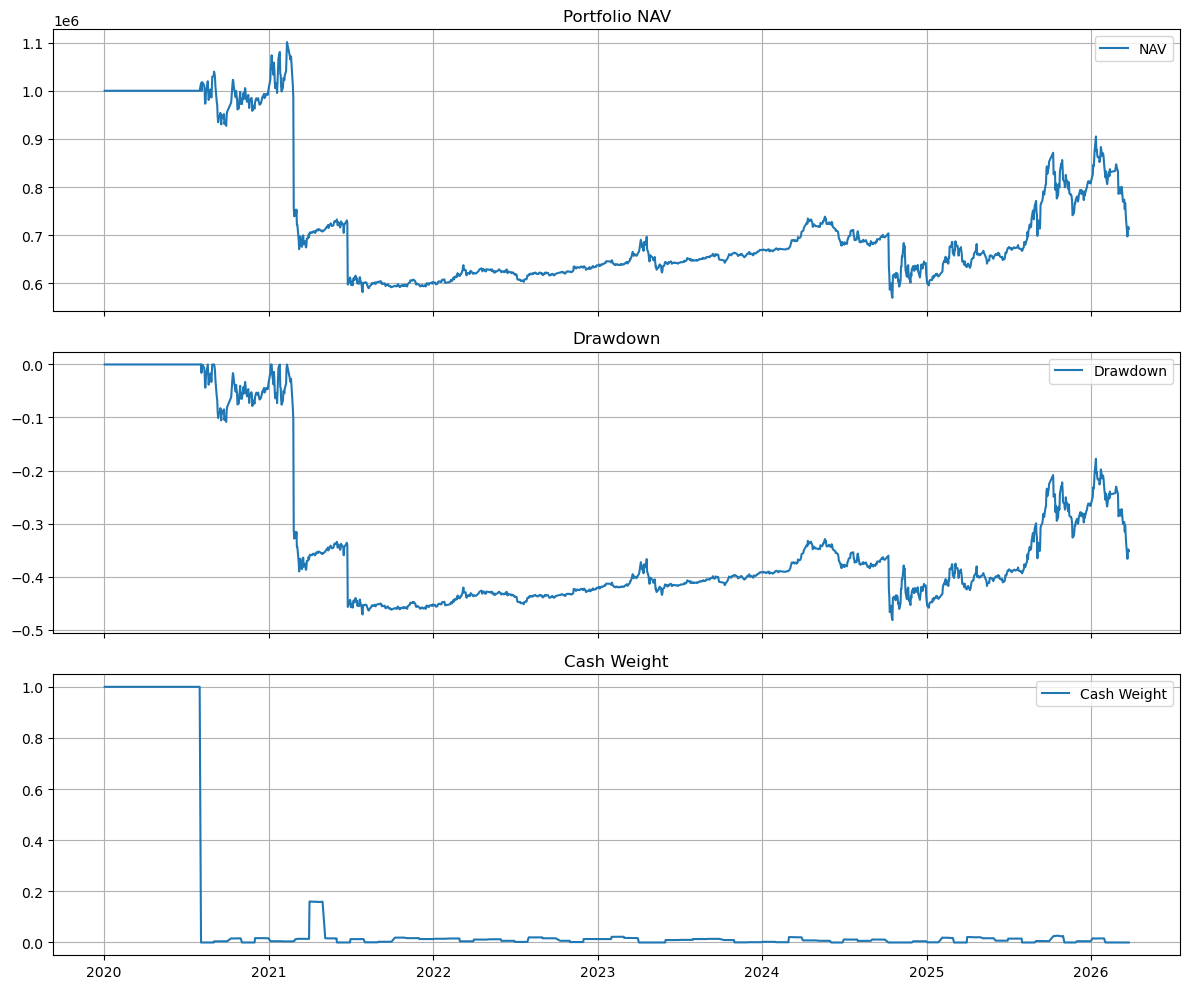

最近净值：


,nav,cash,cash_weight
trade_date,,,
2026-03-20,731256.414062,10.514062,0.000014
2026-03-23,697439.814062,10.514062,0.000015
2026-03-24,711653.914062,10.514062,0.000015
2026-03-25,717152.314062,10.514062,0.000015
2026-03-26,713170.714062,10.514062,0.000015


最近现金占比：


,cash_weight
trade_date,
2026-03-20,0.000014
2026-03-23,0.000015
2026-03-24,0.000015
2026-03-25,0.000015
2026-03-26,0.000015


最近目标权重：


...

最近信号日志：


,signal_date,selected_assets,defensive_assets_used,selected_count,target_cash_weight,market_regime_on
1368,2026-03-12,"512660.SH,510500.SH,512480.SH",,3,0.0,True
1369,2026-03-13,"510500.SH,512660.SH,512480.SH",,3,0.0,True
1370,2026-03-16,"512480.SH,512660.SH,510500.SH",,3,0.0,True
1371,2026-03-17,"512480.SH,512660.SH,510500.SH",,3,0.0,True
1372,2026-03-18,"512660.SH,512480.SH,510500.SH",,3,0.0,True
1373,2026-03-19,,"511010.SH,518880.SH",0,0.0,False
1374,2026-03-20,,"511010.SH,518880.SH",0,0.0,False
1375,2026-03-23,,"511010.SH,518880.SH",0,0.0,False
1376,2026-03-24,,"511010.SH,518880.SH",0,0.0,False
1377,2026-03-25,,"511010.SH,518880.SH",0,0.0,False


最近一次 snapshot 细节：2026-03-25 00:00:00


,close,abs_score,abs_pass,rel_score,rel_rank,selected,target_weight
asset,,,,,,,
510300.SH,4.544,-0.030717,False,NaN,NaN,False,0.0
510500.SH,7.826,0.074115,False,NaN,NaN,False,0.0
159915.SZ,3.307,0.064371,False,NaN,NaN,False,0.0
588000.SH,1.359,-0.015217,False,NaN,NaN,False,0.0
515100.SH,1.461,-0.058027,False,NaN,NaN,False,0.0
512660.SH,1.290,0.027888,False,NaN,NaN,False,0.0
512480.SH,1.451,0.037911,False,NaN,NaN,False,0.0
159928.SZ,0.742,-0.085080,False,NaN,NaN,False,0.0
512170.SH,0.319,-0.085960,False,NaN,NaN,False,0.0


平均现金占比： 0.1029
最大现金占比： 1.0


In [30]:
# ========= 日常查看：净值 / 回撤 / 现金占比 / 最近调仓 / 最近交易 / 最新策略快照 =========
nav = nav_df["nav"].copy()
drawdown = calc_drawdown(nav)
cash_weight = nav_df["cash_weight"].copy() if "cash_weight" in nav_df.columns else (nav_df["cash"] / nav_df["nav"])

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. 净值
axes[0].plot(nav_df.index, nav, label="NAV")
axes[0].set_title("Portfolio NAV")
axes[0].legend()

# 2. 回撤
axes[1].plot(drawdown.index, drawdown, label="Drawdown")
axes[1].set_title("Drawdown")
axes[1].legend()

# 3. 现金占比
axes[2].plot(cash_weight.index, cash_weight, label="Cash Weight")
axes[2].set_title("Cash Weight")
axes[2].legend()

plt.tight_layout()
plt.show()

print("最近净值：")
display(nav_df.tail())

print("最近现金占比：")
display(cash_weight.tail().to_frame("cash_weight"))

print("最近目标权重：")
display(target_weights_df.tail())

print("最近实际权重：")
display(weights_df.tail())

print("最近持仓：")
display(positions_df.tail())

print("最近调仓日志：")
display(rebalance_log_df.tail(10))

print("最近交易记录：")
display(trades_df.tail(20))

print("最近信号日志：")
display(snapshot_log_df.tail(10))

if snapshot_details:
    last_signal_date = max(snapshot_details.keys())
    print(f"最近一次 snapshot 细节：{last_signal_date}")
    display(snapshot_details[last_signal_date])

print("平均现金占比：", round(float(cash_weight.mean()), 4))
print("最大现金占比：", round(float(cash_weight.max()), 4))


C:\Users\12178\AppData\Local\Temp\ipykernel_35520\3033662465.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_ret = close_px.pct_change().dropna(how="all")


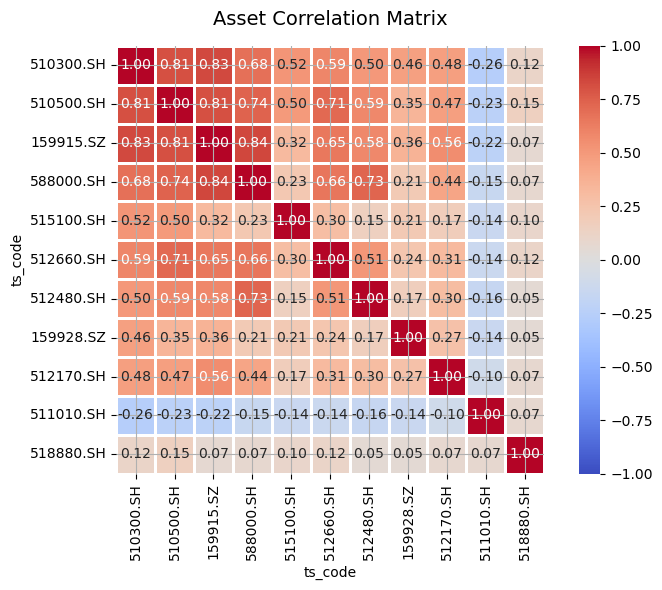

ts_code,510300.SH,510500.SH,159915.SZ,588000.SH,515100.SH,512660.SH,512480.SH,159928.SZ,512170.SH,511010.SH,518880.SH
ts_code,,,,,,,,,,,
510300.SH,1.000000,0.811506,0.832999,0.684403,0.523162,0.591784,0.502391,0.464517,0.476012,-0.262557,0.116076
510500.SH,0.811506,1.000000,0.805903,0.738723,0.496653,0.711654,0.585796,0.350566,0.473902,-0.228107,0.149489
159915.SZ,0.832999,0.805903,1.000000,0.837046,0.319607,0.648869,0.583894,0.362691,0.558819,-0.219531,0.066240
588000.SH,0.684403,0.738723,0.837046,1.000000,0.225593,0.662148,0.729382,0.210144,0.441307,-0.148520,0.073696
515100.SH,0.523162,0.496653,0.319607,0.225593,1.000000,0.296355,0.151953,0.214915,0.174806,-0.141087,0.099209
512660.SH,0.591784,0.711654,0.648869,0.662148,0.296355,1.000000,0.514945,0.239232,0.313576,-0.135478,0.116851
512480.SH,0.502391,0.585796,0.583894,0.729382,0.151953,0.514945,1.000000,0.166408,0.302705,-0.157919,0.048496
159928.SZ,0.464517,0.350566,0.362691,0.210144,0.214915,0.239232,0.166408,1.000000,0.270494,-0.143521,0.052359
512170.SH,0.476012,0.473902,0.558819,0.441307,0.174806,0.313576,0.302705,0.270494,1.000000,-0.099293,0.071041


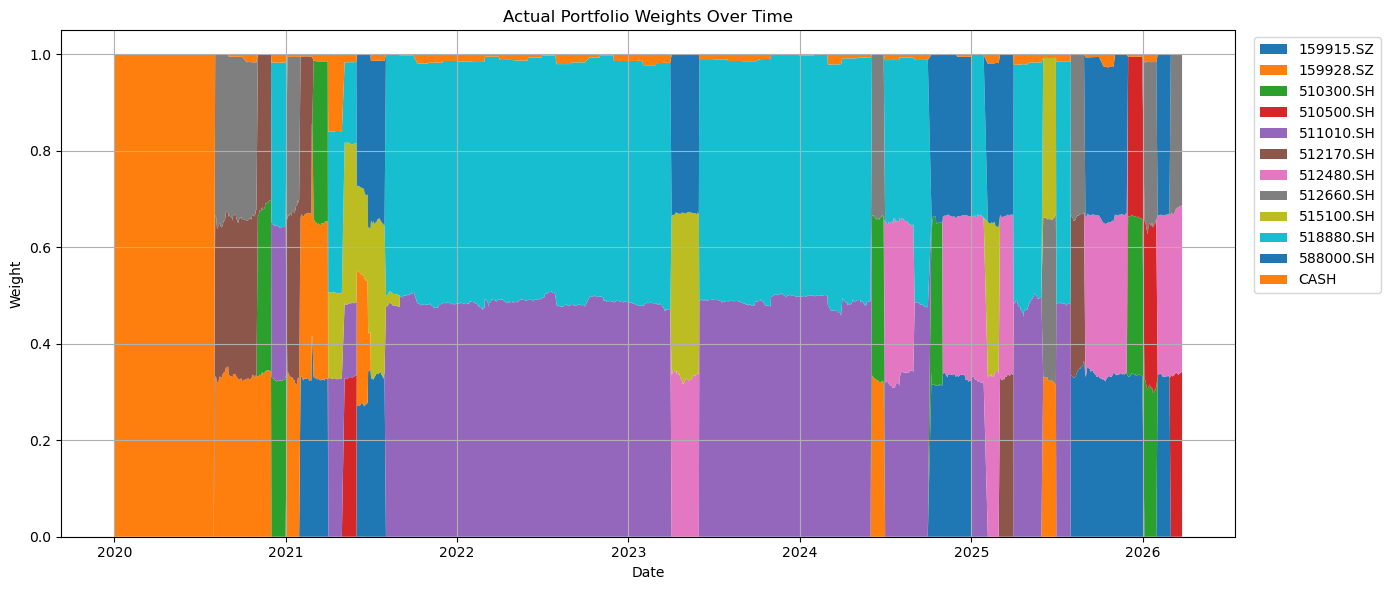

In [31]:
# ========= 资产收益相关性矩阵（基于 close 收益率） + 实际持有比例变化 =========
close_px = market["close"].copy()
asset_ret = close_px.pct_change().dropna(how="all")
asset_corr_matrix = asset_ret[CANDIDATE_ASSETS + DEFENSIVE_ASSETS].corr()

try:
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        asset_corr_matrix,
        annot=True,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        center=0,
        fmt=".2f",
        linewidths=1,
        square=True,
    )
    plt.title("Asset Correlation Matrix", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
except Exception:
    display(asset_corr_matrix)

display(asset_corr_matrix)

actual_weights_plot = weights_df.copy().fillna(0.0)

plt.figure(figsize=(14, 6))
plt.stackplot(
    actual_weights_plot.index,
    actual_weights_plot.T.values,
    labels=actual_weights_plot.columns
)
plt.title("Actual Portfolio Weights Over Time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()


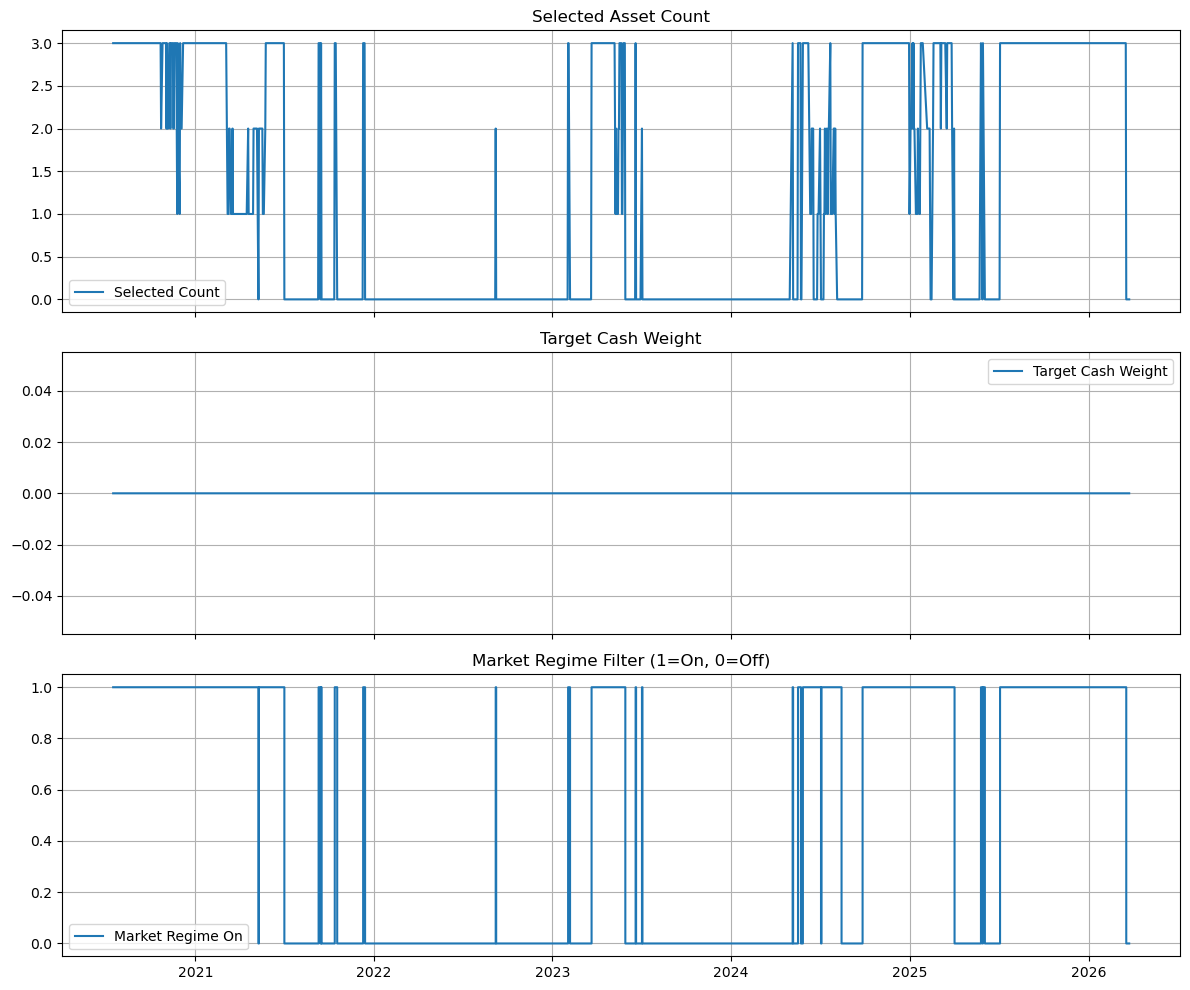

资产入选频率：


,selected_count,selected_ratio
ts_code,,
512480.SH,303,0.219884
159915.SZ,289,0.209724
588000.SH,260,0.188679
512660.SH,221,0.160377
159928.SZ,171,0.124093
515100.SH,143,0.103774
512170.SH,123,0.089260
510300.SH,92,0.066763
510500.SH,75,0.054427


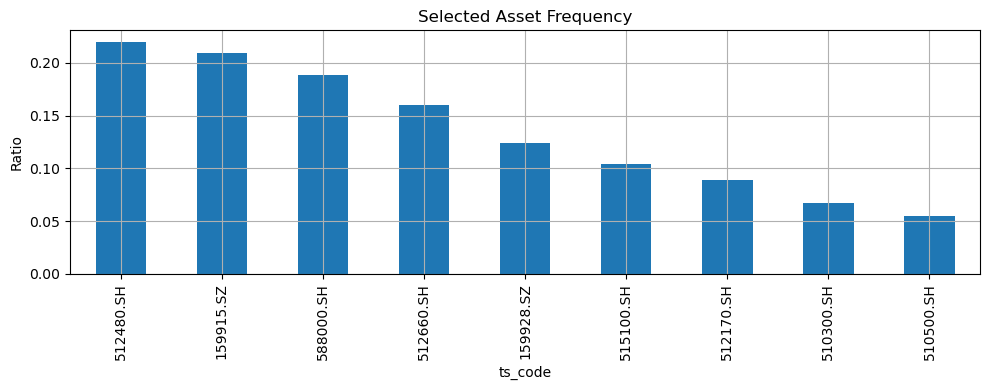

最近一次 snapshot 明细（2026-03-25 00:00:00）：


,close,abs_score,abs_pass,rel_score,rel_rank,selected,target_weight
asset,,,,,,,
510300.SH,4.544,-0.030717,False,NaN,NaN,False,0.0
510500.SH,7.826,0.074115,False,NaN,NaN,False,0.0
159915.SZ,3.307,0.064371,False,NaN,NaN,False,0.0
588000.SH,1.359,-0.015217,False,NaN,NaN,False,0.0
515100.SH,1.461,-0.058027,False,NaN,NaN,False,0.0
512660.SH,1.290,0.027888,False,NaN,NaN,False,0.0
512480.SH,1.451,0.037911,False,NaN,NaN,False,0.0
159928.SZ,0.742,-0.085080,False,NaN,NaN,False,0.0
512170.SH,0.319,-0.085960,False,NaN,NaN,False,0.0


In [32]:
# ========= 双动量专属分析：选中资产数量 / 目标现金 / 资产入选频率 / 最新明细 =========
if len(snapshot_log_df) > 0:
    tmp = snapshot_log_df.copy()
    tmp["signal_date"] = pd.to_datetime(tmp["signal_date"])
    tmp = tmp.set_index("signal_date").sort_index()

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(tmp.index, tmp["selected_count"], label="Selected Count")
    axes[0].set_title("Selected Asset Count")
    axes[0].legend()

    axes[1].plot(tmp.index, tmp["target_cash_weight"], label="Target Cash Weight")
    axes[1].set_title("Target Cash Weight")
    axes[1].legend()

    market_regime_num = tmp["market_regime_on"].astype(int)
    axes[2].step(tmp.index, market_regime_num, where="post", label="Market Regime On")
    axes[2].set_title("Market Regime Filter (1=On, 0=Off)")
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # 统计各资产被选中的次数
    selected_pairs = []
    for dt, s in tmp["selected_assets"].fillna("").items():
        codes = [x.strip() for x in str(s).split(",") if x.strip()]
        for code in codes:
            selected_pairs.append((dt, code))

    if len(selected_pairs) > 0:
        selected_df = pd.DataFrame(selected_pairs, columns=["signal_date", "ts_code"])
        selected_freq = selected_df["ts_code"].value_counts().rename("selected_count").to_frame()
        selected_freq["selected_ratio"] = selected_freq["selected_count"] / len(tmp)
        print("资产入选频率：")
        display(selected_freq)

        plt.figure(figsize=(10, 4))
        selected_freq["selected_ratio"].sort_values(ascending=False).plot(kind="bar")
        plt.title("Selected Asset Frequency")
        plt.ylabel("Ratio")
        plt.tight_layout()
        plt.show()
    else:
        print("snapshot_log_df 中没有 selected_assets 记录")

    if snapshot_details:
        last_signal_date = max(snapshot_details.keys())
        detail = snapshot_details[last_signal_date].copy()
        if {"selected", "rel_score"}.issubset(detail.columns):
            detail = detail.sort_values(["selected", "rel_score"], ascending=[False, False])
        print(f"最近一次 snapshot 明细（{last_signal_date}）：")
        display(detail)
else:
    print("没有 snapshot_log_df，无法做双动量信号分析")


C:\Users\12178\AppData\Local\Temp\ipykernel_35520\2307733415.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  year_end_nav = nav.resample("Y").last()


,annual_return
trade_date,
2020,NaN
2021,-0.399289
2022,0.057205
2023,0.049473
2024,-0.073230
2025,0.302782
2026,-0.116879


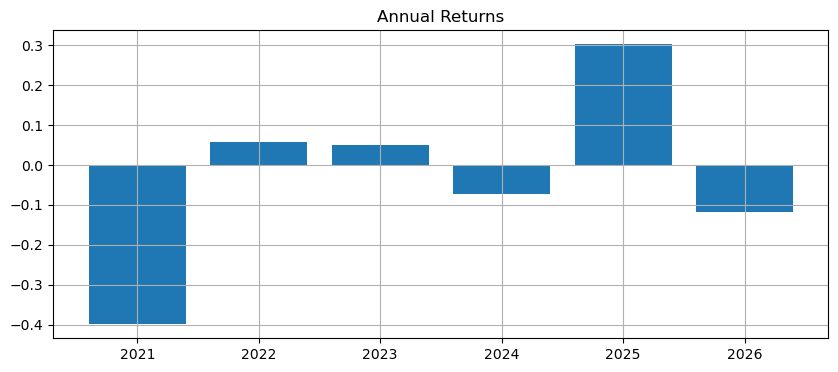

C:\Users\12178\AppData\Local\Temp\ipykernel_35520\2307733415.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_end_nav = nav.resample("M").last()


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,nan%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,3.01%,-7.19%,1.78%,-1.06%,4.23%
2021,-0.50%,-25.95%,-5.78%,1.59%,3.24%,-16.20%,-1.99%,0.50%,-1.85%,0.65%,0.27%,0.90%
2022,-0.30%,2.49%,0.59%,1.57%,-0.66%,-0.80%,-0.61%,0.50%,0.07%,0.67%,1.35%,0.76%
2023,0.94%,-0.61%,3.49%,-0.51%,-2.14%,-0.29%,0.76%,1.19%,-0.82%,2.16%,-0.33%,1.12%
2024,0.37%,0.09%,5.24%,1.71%,0.80%,-5.52%,2.90%,-2.42%,1.12%,-12.79%,3.77%,-1.51%
2025,-0.92%,7.98%,-4.44%,4.00%,-0.71%,2.85%,-0.40%,13.54%,12.06%,-4.42%,-5.15%,4.43%
2026,5.16%,-0.80%,-15.34%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


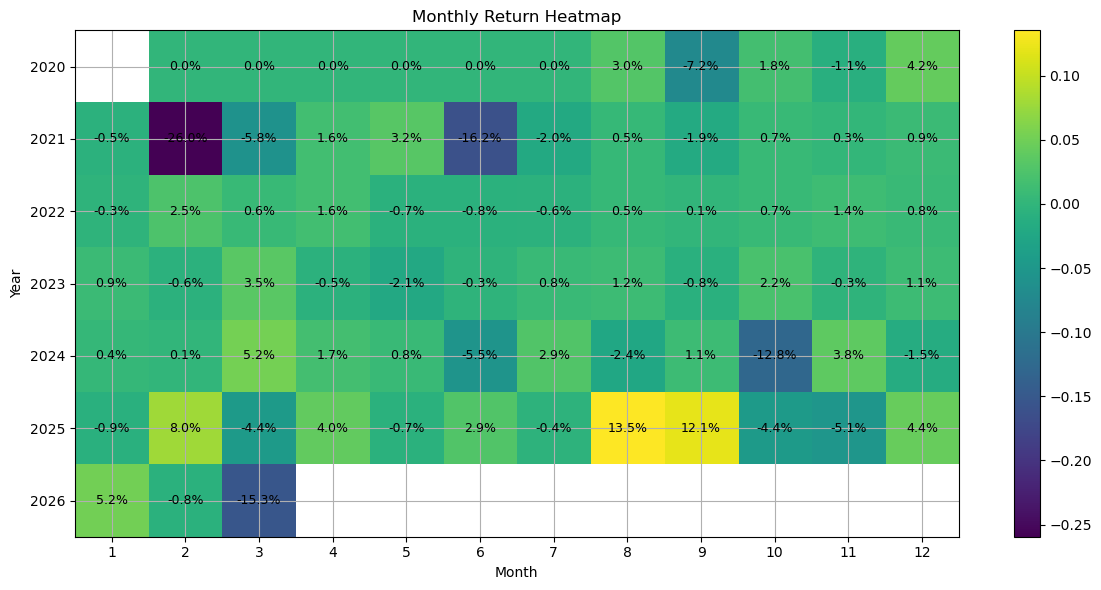

In [33]:
# ========= 年度收益 / 月度收益热力图 =========
year_end_nav = nav.resample("Y").last()
annual_returns = year_end_nav.pct_change()
annual_returns.index = annual_returns.index.year

annual_returns_df = annual_returns.to_frame("annual_return")
display(annual_returns_df)

plt.figure(figsize=(10, 4))
plt.bar(annual_returns_df.index.astype(str), annual_returns_df["annual_return"])
plt.title("Annual Returns")
plt.show()

month_end_nav = nav.resample("M").last()
monthly_returns = month_end_nav.pct_change()
monthly_df = monthly_returns.to_frame("monthly_return")
monthly_df["year"] = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month

heatmap_table = monthly_df.pivot(index="year", columns="month", values="monthly_return")
display(heatmap_table.style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_table.values, aspect="auto")

ax.set_xticks(range(len(heatmap_table.columns)))
ax.set_xticklabels(heatmap_table.columns)
ax.set_yticks(range(len(heatmap_table.index)))
ax.set_yticklabels(heatmap_table.index)

ax.set_title("Monthly Return Heatmap")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

for i in range(heatmap_table.shape[0]):
    for j in range(heatmap_table.shape[1]):
        val = heatmap_table.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


调仓日志：


,signal_date,trade_date,reason,drift_value,turnover,target_cash_weight,cash_weight_before_trade,cash_weight_after_trade,cash_after_trade,traded,trade_count,execution_policy,blocked_assets,partial_execution,signal_cleared,year
48,2024-07-31,2024-08-01,schedule,NaN,0.033838,0.0,0.011391,0.006190,4362.498987,1,3,best_effort,,0,1,2024
49,2024-08-30,2024-09-02,schedule,NaN,0.613543,0.0,0.006344,0.011584,7920.405237,1,3,best_effort,,0,1,2024
50,2024-09-30,2024-10-08,schedule,NaN,1.988568,0.0,0.011389,0.000043,26.253100,1,6,best_effort,,0,1,2024
51,2024-10-31,2024-11-01,schedule,NaN,0.700512,0.0,0.000043,0.000048,29.355100,1,5,best_effort,,0,1,2024
52,2024-11-29,2024-12-02,schedule,NaN,0.013448,0.0,0.000047,0.004879,3070.556725,1,3,best_effort,,0,1,2024
53,2024-12-31,2025-01-02,schedule,NaN,1.317793,0.0,0.004954,0.000758,461.569187,1,339,best_effort,,0,1,2025
54,2025-01-27,2025-02-05,schedule,NaN,1.333254,0.0,0.000752,0.019472,12022.376037,1,5,best_effort,,0,1,2025
55,2025-02-28,2025-03-03,schedule,NaN,0.636538,0.0,0.018128,0.000034,22.358725,1,4,best_effort,,0,1,2025
56,2025-03-31,2025-04-01,schedule,NaN,1.978625,0.0,0.000035,0.021340,13574.736450,1,5,best_effort,,0,1,2025
57,2025-04-30,2025-05-06,schedule,NaN,0.038438,0.0,0.020596,0.016461,10852.968075,1,2,best_effort,,0,1,2025


,rebalance_count,turnover_sum,partial_execution_count
year,,,
2020,5,3.025866,0
2021,12,9.833663,0
2022,12,0.127486,0
2023,12,4.077577,0
2024,12,7.420109,0
2025,12,13.965163,0
2026,3,3.985266,0


count          sum
ts_code   side                    
159915.SZ BUY       7  1280235.525
          SELL     11  1295170.350
159928.SZ BUY       6  1330396.650
          SELL      9  1135071.350
510300.SH BUY       6  1302391.900
          SELL      6  1290221.475
510500.SH BUY       3   768050.750
          SELL      3   538179.350
511010.SH BUY      16  2401682.825
          SELL     12  2429223.325
512170.SH BUY    6048  1121655.550
          SELL      7   909376.300
512480.SH BUY    3874  1210307.600
          SELL      8   926370.450
512660.SH BUY      10  1894613.525
          SELL      7  1593450.225
515100.SH BUY       6   941194.600
          SELL      7   950531.200
518880.SH BUY     371  2391777.575
          SELL     26  2595048.725
588000.SH BUY      45  1402972.650
          SELL     11  1398199.975

side
BUY     8022.639575
SELL    7530.421363
Name: total_cost, dtype: float64

最后一期实际权重：


,last_weight
512480.SH,0.344250
510500.SH,0.341181
512660.SH,0.314554
CASH,0.000015
510300.SH,0.000000
159928.SZ,0.000000
159915.SZ,0.000000
512170.SH,0.000000
511010.SH,0.000000
515100.SH,0.000000


样本期平均实际权重：


,avg_weight
518880.SH,0.267859
511010.SH,0.260083
CASH,0.102881
512480.SH,0.060650
159915.SZ,0.056692
588000.SH,0.055627
159928.SZ,0.042191
512660.SH,0.039168
512170.SH,0.033940
510300.SH,0.032293


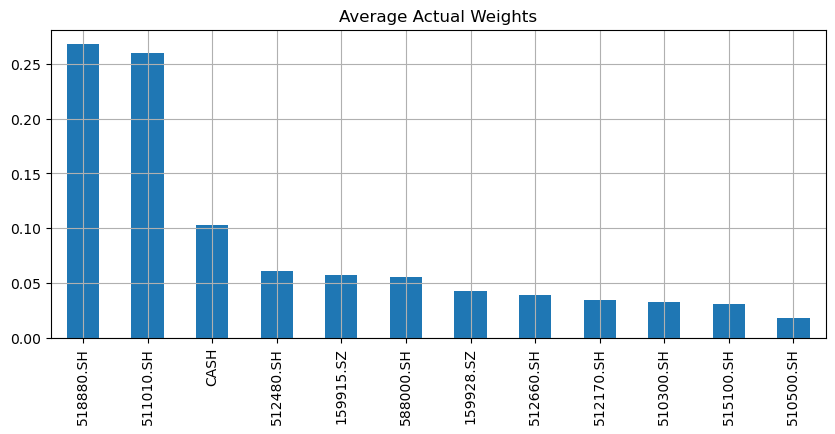

最近实际权重 vs 目标权重：


,actual_weight,target_weight,diff
518880.SH,0.000000,0.5,-0.500000
511010.SH,0.000000,0.5,-0.500000
159915.SZ,0.000000,0.0,0.000000
159928.SZ,0.000000,0.0,0.000000
510500.SH,0.341181,0.0,0.341181
510300.SH,0.000000,0.0,0.000000
512480.SH,0.344250,0.0,0.344250
512170.SH,0.000000,0.0,0.000000
512660.SH,0.314554,0.0,0.314554
515100.SH,0.000000,0.0,0.000000


最近持仓：


,shares
ts_code,
512660.SH,173900
512480.SH,169200
510500.SH,31600
510300.SH,0
159928.SZ,0
159915.SZ,0
511010.SH,0
512170.SH,0
515100.SH,0


In [34]:
# ========= 调仓统计 / 交易统计 / 权重分析 / 最近持仓与目标权重对比 =========
if len(rebalance_log_df) > 0:
    rebalance_log_df["trade_date"] = pd.to_datetime(rebalance_log_df["trade_date"])
    rebalance_log_df["year"] = rebalance_log_df["trade_date"].dt.year

    print("调仓日志：")
    display(rebalance_log_df.tail(20))

    yearly_rebalance_count = rebalance_log_df.groupby("year").size().rename("rebalance_count")
    yearly_turnover = rebalance_log_df.groupby("year")["turnover"].sum().rename("turnover_sum")

    extra_cols = [c for c in ["partial_execution", "signal_cleared"] if c in rebalance_log_df.columns]
    agg_frames = [yearly_rebalance_count, yearly_turnover]
    if "partial_execution" in rebalance_log_df.columns:
        yearly_partial = rebalance_log_df.groupby("year")["partial_execution"].sum().rename("partial_execution_count")
        agg_frames.append(yearly_partial)

    display(pd.concat(agg_frames, axis=1))
else:
    print("没有调仓记录")

if len(trades_df) > 0:
    trade_summary = trades_df.groupby(["ts_code", "side"])["trade_value"].agg(["count", "sum"])
    display(trade_summary)

    fee_summary = trades_df.groupby("side")["cost"].sum().rename("total_cost")
    display(fee_summary)
else:
    print("没有交易记录")

print("最后一期实际权重：")
display(
    weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "last_weight"})
    .sort_values("last_weight", ascending=False)
)

print("样本期平均实际权重：")
avg_weight = weights_df.mean().sort_values(ascending=False).to_frame("avg_weight")
display(avg_weight)

plt.figure(figsize=(10, 4))
avg_weight["avg_weight"].plot(kind="bar")
plt.title("Average Actual Weights")
plt.show()

if len(weights_df) > 0 and len(target_weights_df) > 0:
    last_actual = weights_df.tail(1).T.rename(columns={weights_df.index[-1]: "actual_weight"})
    last_target = target_weights_df.tail(1).T.rename(columns={target_weights_df.index[-1]: "target_weight"})
    compare = last_actual.join(last_target, how="outer").fillna(0.0)
    compare["diff"] = compare["actual_weight"] - compare["target_weight"]
    print("最近实际权重 vs 目标权重：")
    display(compare.sort_values("target_weight", ascending=False))

print("最近持仓：")
display(positions_df.tail(1).T.rename(columns={positions_df.index[-1]: "shares"}).sort_values("shares", ascending=False))


In [35]:
# ========= 一键导出 =========
nav_df.to_csv(EXPORT_DIR / "nav.csv")
weights_df.to_csv(EXPORT_DIR / "weights.csv")
positions_df.to_csv(EXPORT_DIR / "positions.csv")
target_weights_df.to_csv(EXPORT_DIR / "target_weights.csv")
trades_df.to_csv(EXPORT_DIR / "trades.csv", index=False)
rebalance_log_df.to_csv(EXPORT_DIR / "rebalance_log.csv", index=False)
snapshot_log_df.to_csv(EXPORT_DIR / "snapshot_log.csv", index=False)
summary.to_csv(EXPORT_DIR / "summary.csv")
asset_corr_matrix.to_csv(EXPORT_DIR / "asset_corr_matrix.csv")

if snapshot_details:
    snapshot_detail_dir = EXPORT_DIR / "snapshot_details"
    snapshot_detail_dir.mkdir(parents=True, exist_ok=True)
    for dt, df in snapshot_details.items():
        dt_str = pd.Timestamp(dt).strftime("%Y%m%d")
        df.to_csv(snapshot_detail_dir / f"snapshot_detail_{dt_str}.csv")

print("export done")


export done


In [36]:
# ========= 可选：快速改参数重跑 =========
# 这里只留几个最常用示例，避免 notebook 过长

# BACKTEST_PARAMS["rebalance_freq"] = "W-FRI"
# BACKTEST_PARAMS["use_drift_trigger"] = True
# BACKTEST_PARAMS["drift_threshold"] = 0.08

# DM_SNAPSHOT_KWARGS["top_k"] = 1
# DM_SNAPSHOT_KWARGS["weighting"] = "score"
# DM_SNAPSHOT_KWARGS["rel_risk_adjusted"] = True
# DM_SNAPSHOT_KWARGS["fill_unallocated_to_defensive"] = True
# DM_SNAPSHOT_KWARGS["abs_ma_window"] = None
# DM_SNAPSHOT_KWARGS["market_asset"] = None

# result = simulate_dual_momentum_backtest(
#     market=market,
#     initial_cash=BACKTEST_PARAMS["initial_cash"],
#     rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
#     execution_price_type=BACKTEST_PARAMS["execution_price_type"],
#     valuation_ffill_limit=BACKTEST_PARAMS["valuation_ffill_limit"],
#     fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
#     fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
#     lot_size=BACKTEST_PARAMS["lot_size"],
#     max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
#     amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
#     use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
#     drift_threshold=BACKTEST_PARAMS["drift_threshold"],
#     dm_prepare_kwargs=DM_PREPARE_KWARGS,
#     dm_snapshot_kwargs=DM_SNAPSHOT_KWARGS,
#     risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
#     annualization=BACKTEST_PARAMS["annualization"],
#     include_cash_column=True,
#     cash_column_name="CASH",
#     store_snapshot_details=True,
#     execution_policy=BACKTEST_PARAMS["execution_policy"],
# )
